In [92]:
#Standard Packages:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import MonthEnd

#YahooFinance:
from pandas_datareader import data as pdr
import yfinance as yf


#Statsmodels:
import statsmodels.api as sma
import statsmodels as sm
from statsmodels import tsa
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import t, probplot

In [107]:
#Importing historic price data using yfinance
ticker = 'BBCA.JK'
stockTicker = yf.Ticker(ticker)
hist = stockTicker.history(period='1y')

#For forecasting purposes I reset my index to integers:
hist = hist.reset_index()

In [108]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Historic Stock Price'
)

fig.show()

In [109]:
#Order of integration
adf = adfuller(x=hist['Close'],
                  autolag='BIC')
print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

ADF Statistic: -1.149512787729865
p-value: 0.6949286085408729


In [110]:
# Membuat kolom baru berisi selisih harga (differencing)
hist['Diff_1'] = hist['Close']

# Uji kembali dengan ADF pada data yang sudah di-diff
adf_diff = adfuller(hist['Diff_1'].dropna(), autolag='BIC')

print(f'ADF Statistic (Setelah Diff): {adf_diff[0]}')
print(f'p-value (Setelah Diff): {adf_diff[1]}')

ADF Statistic (Setelah Diff): -1.149512787729865
p-value (Setelah Diff): 0.6949286085408729


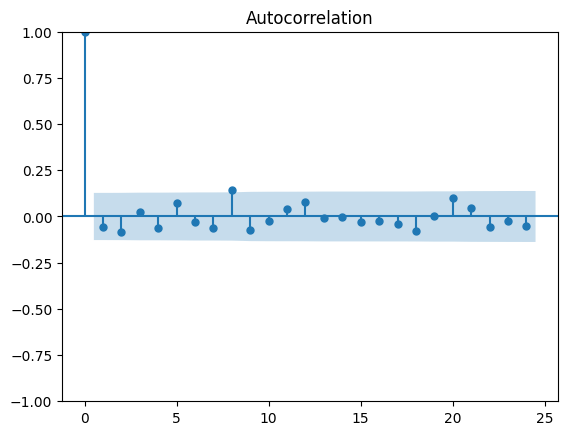

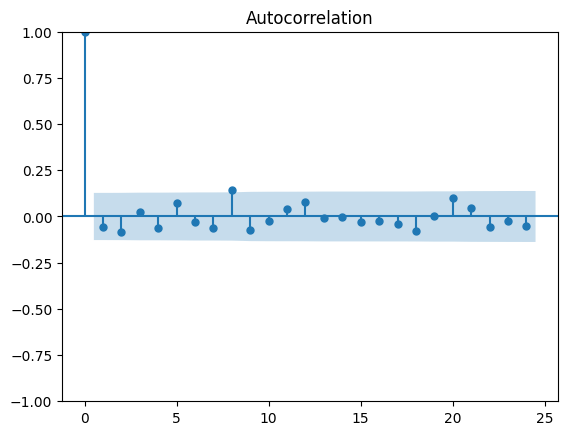

In [111]:
# Gunakan .diff() dan .dropna() agar data stasioner
sma.graphics.tsa.plot_acf(hist['Close'].diff().dropna())

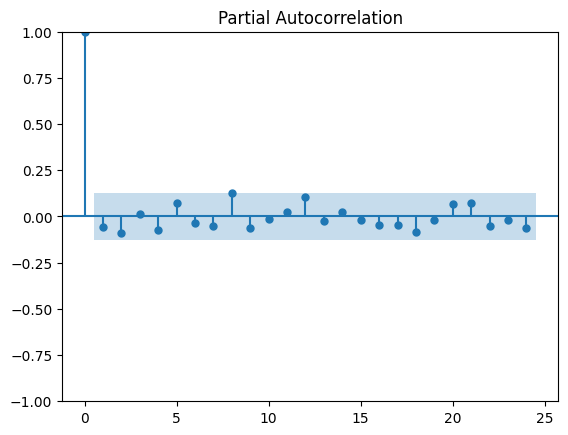

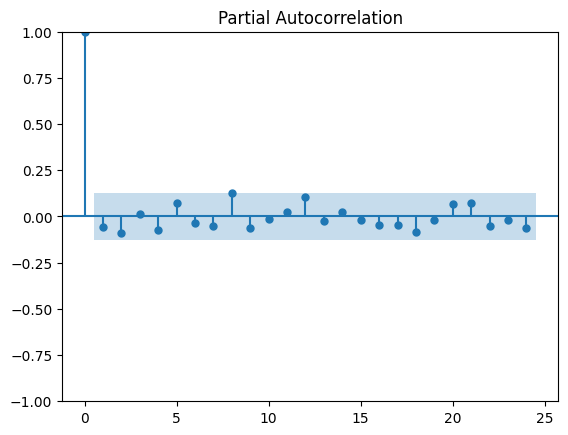

In [112]:
# Plot PACF pada data yang sudah stasioner
sma.graphics.tsa.plot_pacf(hist['Close'].diff().dropna())

In [113]:
#Significant AR lags:
pacf_coef = pacf(hist['Close'].diff().dropna(), alpha=.05)
sig_pacf = []
for i in range(1, len(pacf_coef[0])):
    if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
        sig_pacf.append(i)
    elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
        sig_pacf.append(i)

sig_pacf

[8]

In [114]:
def get_arima_price(df, fact, forecast_steps):

    #MA Lags
    acf_coef = acf(df[fact].diff().dropna(), alpha=.05)
    sig_acf = []
    for i in range(1, len(acf_coef[0])):
        if acf_coef[0][i] > (acf_coef[1][i][1] - acf_coef[0][i]):
            sig_acf.append(i)
        elif acf_coef[0][i] < (acf_coef[1][i][0] - acf_coef[0][i]):
            sig_acf.append(i)

    #AR Lags
    pacf_coef = pacf(df[fact].diff().dropna(), alpha=.05)
    sig_pacf = []
    for i in range(1, len(pacf_coef[0])):
        if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
            sig_pacf.append(i)
        elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
            sig_pacf.append(i)

    #Order of integration
    adf = adfuller(x=df[fact],
                  autolag='BIC')
    order = 0
    if adf[0] < adf[4]['5%']:
        order = 0
    else:
        order = 1

    #Trend indication
    if order == 1:
        trend = 't'
    else:
        trend = 'c'
    # Ambil nilai maksimal agar menjadi integer
    p = max(sig_pacf) if sig_pacf else 0
    q = max(sig_acf) if sig_acf else 0
    d = order # hasil dari pengecekan ADF

    model = ARIMA(endog = df[fact],
                  order = (p, d, q),
                  trend = trend).fit()

    forecast = model.get_forecast(forecast_steps, alpha=0.05)

    predict = model.predict()

    return forecast.summary_frame(), model.summary(), predict

In [115]:
# Mencoba prediksi untuk 10 hari ke depan
hasil_forecast, ringkasan, hasil_predict = get_arima_price(hist, 'Close', 30)

# Intip hasil prediksinya
print(hasil_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Close         mean     mean_se  mean_ci_lower  mean_ci_upper
237    6695.185508  127.833930    6444.635609    6945.735407
238    6746.918645  184.108074    6386.073451    7107.763839
239    6719.070128  218.445230    6290.925346    7147.214911
240    6693.967673  250.636132    6202.729882    7185.205465
241    6735.439989  274.173254    6198.070285    7272.809693
242    6668.150428  296.620464    6086.785003    7249.515854
243    6710.852909  317.632063    6088.305506    7333.400312
244    6661.257340  333.661743    6007.292341    7315.222339
245    6678.911619  354.578963    5983.949622    7373.873616
246    6652.104703  370.013057    5926.892438    7377.316968
247    6649.851883  387.095551    5891.158544    7408.545222
248    6651.334604  403.263389    5860.952885    7441.716323
249    6610.837148  417.890674    5791.786476    7429.887819
250    6644.932765  433.084399    5796.102940    7493.762589
251    6592.342451  447.725957    5714.815701    7469.869202
252    6612.622674  462.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [119]:
# 1. Jalankan fungsi untuk mendapatkan hasil
# Kita asumsikan memprediksi 30 hari ke depan
forecast_df, summary, predict_values = get_arima_price(hist, 'Close', 30)

# 2. Buat grafik perbandingan
fig = go.Figure()

# Garis Harga Asli
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=hist['Close'],
    mode='lines',
    name='Harga Asli (Actual)',
    line=dict(color='blue')
))

# Garis Prediksi pada data historis (In-sample prediction)
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=predict_values,
    mode='lines',
    name='Prediksi Model (In-sample)',
    line=dict(color='orange', dash='dot')
))

# Garis Peramalan Masa Depan (Out-of-sample forecast)
# Kita buat index tanggal untuk masa depan
last_date = hist['Date'].iloc[-1]
forecast_dates = [last_date + relativedelta(days=i) for i in range(1, 31)]

fig.add_trace(go.Scatter(
    x=forecast_dates,
    y=forecast_df['mean'],
    mode='lines',
    name='Ramalan 30 Hari (Forecast)',
    line=dict(color='red', width=3)
))

# Menambahkan Area Ketidakpastian (Confidence Interval)
fig.add_trace(go.Scatter(
    x=forecast_dates + forecast_dates[::-1],
    y=pd.concat([forecast_df['mean_ci_upper'], forecast_df['mean_ci_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.1)',
    line=dict(color='rgba(255, 0, 0, 0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Batas Ketidakpastian'
))

fig.update_layout(
    title='Analisis Prediksi Harga Saham BBCA.JK (Model ARIMA)',
    xaxis_title='Tanggal',
    yaxis_title='Harga (IDR)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [103]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines', name = 'Observed'))
fig.add_trace(go.Scatter(x = predict.index[1:], y = predict[1:], mode = 'lines', name = 'ARIMA Model Prediction'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean'], mode = 'lines', name = 'ARIMA Model Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_lower'], mode = 'lines', name = 'Forecast Error', line=dict(color='darkblue')))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_upper'], mode = 'lines', line=dict(color='darkblue'), showlegend = False))
fig.add_trace(go.Scatter(x = [predict.index[-1], forecast_df.index[0]], y = [predict.iloc[-1], forecast_df['mean'].iloc[0]], mode = 'lines', name = 'ARIMA Model 1-Day Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index[:4], y = forecast_df['mean'].iloc[:4], mode = 'lines', name = 'ARIMA Model 4-Day Forecast (Higher Accuracy)'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Stock Price'
)

fig.show()

In [104]:
print(hasil_forecast['mean'])

235    6769.664729
236    6764.329457
237    6758.994186
238    6753.658914
239    6748.323643
240    6742.988371
241    6737.653100
242    6732.317829
243    6726.982557
244    6721.647286
245    6716.312014
246    6710.976743
247    6705.641471
248    6700.306200
249    6694.970928
250    6689.635657
251    6684.300386
252    6678.965114
253    6673.629843
254    6668.294571
255    6662.959300
256    6657.624028
257    6652.288757
258    6646.953486
259    6641.618214
260    6636.282943
261    6630.947671
262    6625.612400
263    6620.277128
264    6614.941857
Name: mean, dtype: float64


In [105]:
# 1. Simpan tabel forecast ke dalam file CSV
# Kita ambil hasil dari variabel forecast_df yang berisi mean dan confidence interval
forecast_df.to_excel('hasil_prediksi_arima_bbca.xlsx', index=True)

# 2. Perintah untuk mengunduh file ke komputer lokal (khusus Google Colab)
from google.colab import files
files.download('hasil_prediksi_arima_bbca.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
# 1. Ambil hanya kolom 'mean' saja
prediksi_hanya_mean = hasil_forecast[['mean']]

# 2. Simpan ke file XLSX
file_output = 'prediksi_mean_bbca.xlsx'
prediksi_hanya_mean.to_excel(file_output, index=True)

# 3. Download file ke komputer lokal
from google.colab import files
files.download(file_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>